# Deep Learning for Media
#### MPATE-GE 2039 - DM-GY 9103

---

## VR Chinese OCR Evaluation
### Representation Analysis



## Setup

In [ ]:
# Import unified utils from /utils 
# THis takes care of all the utils.py from data/, evaluation/ and models/
import sys
import importlib
from pathlib import Path

# Make project root importable when running notebook from notebooks/
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import utils as u
importlib.reload(u)
u

<module 'utils' from '/Users/ek/Documents/GitHub/vr-chinese-ocr-eval/utils/__init__.py'>

In [ ]:
# Utilities loaded from setup cell above
u

<module 'data.utils' from '/Users/ek/Documents/GitHub/vr-chinese-ocr-eval/data/utils.py'>

In [14]:
# Fix the random seed for reproducibility
from numpy.random import seed
seed(124)
import tensorflow as tf
tf.keras.utils.set_random_seed(124)

## Load dataset, perturbate, & split

1. Load the CASIA-HWDB2 dataset: https://huggingface.co/datasets/Teklia/CASIA-HWDB2-line?library=datasets
2. Perturbation methods currently implemented:
   - Radial glare spot
   - Directional light streak
   - Gaussian noise (camera/sensor-style noise)
   - Contrast / lighting variation
   - Occlusion (hand blocking strokes style)
3. Build perturbation buckets (single-type or combination buckets)
4. Apply perturbations on a disjoint pool (outside clean samples)
5. Merge clean + perturbated samples and split into train/test

6. Augment the dataset with perturbated data
From our presentation: ~1000-1500 clean data from existing dataset + 200-300 perturbated data
Revision that I suggested: 1500 clean data + 31 (perturb_bucket_count) * 50 (min_per_perturb_bucket) = 1550 perturbated data
Note: 31 (perturb_bucket_count) comes from the Power Set of the number of perturbation_type we're doing (so far we're doing 5 types). Basically there are 31 combinations of perturbation types we can performed.

7. Split the train data into 0.8 -> train & 0.2 -> val

In [35]:
# Load data (with progress bar + metadata)
# Note: already comes with perturbation + augmentation
# Checkout the utils.load_data() function for more options and details on the returned data
(
    X_train,
    X_test,
    y_train,
    y_test,
    perturbation_type_train,
    perturbation_type_test,
) = u.load_data(
    show_progress=True,
    perturb_count=None,
    include_combinations=True,
    min_per_perturb_bucket=50,
    return_perturbation_type=True,
)

Applying perturbations: 100%|██████████| 1550/1550 [00:11<00:00, 130.03it/s]


In [25]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) # check data dimensions X.shape==(samples, features)

(2440,) (610,) (2440,) (610,)


In [26]:
# Split data
X_train, X_val, y_train, y_val = u.split_data(X_train, y_train)

In [27]:
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape) # check data dimensions X.shape==(samples, features)

(1952,) (488,) (1952,) (488,)


/Users/ek/Documents/GitHub/vr-chinese-ocr-eval/utils/utils.py:324: UserWarning: Glyph 24208 (\N{CJK UNIFIED IDEOGRAPH-5E90}) missing from font(s) DejaVu Sans.
  
/Users/ek/Documents/GitHub/vr-chinese-ocr-eval/utils/utils.py:324: UserWarning: Glyph 23665 (\N{CJK UNIFIED IDEOGRAPH-5C71}) missing from font(s) DejaVu Sans.
  
/Users/ek/Documents/GitHub/vr-chinese-ocr-eval/utils/utils.py:324: UserWarning: Glyph 35875 (\N{CJK UNIFIED IDEOGRAPH-8C23}) missing from font(s) DejaVu Sans.
  
/Users/ek/Documents/GitHub/vr-chinese-ocr-eval/utils/utils.py:324: UserWarning: Glyph 23492 (\N{CJK UNIFIED IDEOGRAPH-5BC4}) missing from font(s) DejaVu Sans.
  
/Users/ek/Documents/GitHub/vr-chinese-ocr-eval/utils/utils.py:324: UserWarning: Glyph 21346 (\N{CJK UNIFIED IDEOGRAPH-5362}) missing from font(s) DejaVu Sans.
  
/Users/ek/Documents/GitHub/vr-chinese-ocr-eval/utils/utils.py:324: UserWarning: Glyph 20365 (\N{CJK UNIFIED IDEOGRAPH-4F8D}) missing from font(s) DejaVu Sans.
  
/Users/ek/Documents/GitHub/v

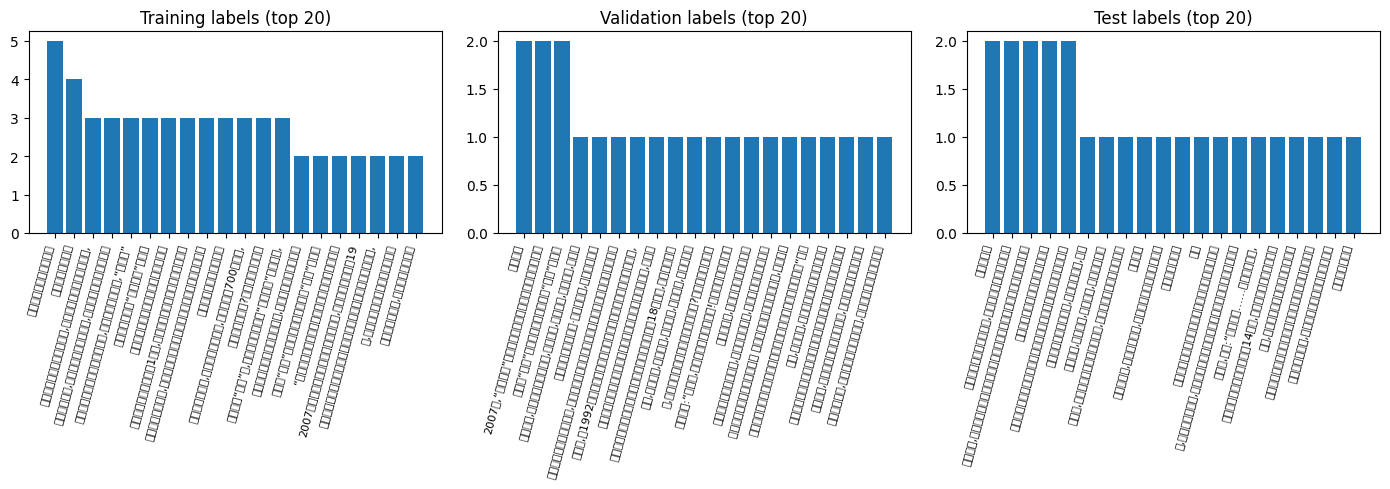

In [37]:
u.explore_data(X_train, y_train, y_test, y_val)

## Train & test on top various pretrained models

### Pretrained Handwriting-Specific Models
1. CnOCR→ PyTorch based, 20+ pretrained Chinese OCR models, easy to set up
2. ANCHOR → VGG CNN built specifically for handwritten Chinese, 97% accuracy on ICDAR 2013
3. TrOCR→ Microsoft transformer model trained on handwritten and real world scene text, closest to whiteboard conditions

### General Purpose Model
1. DINOv3→  Meta's self supervised vision transformer, 1.7B training images, not Chinese specific
Included as a baseline to test whether a powerful general model can compete with specialized ones under perturbation


In [ ]:
# Build baseline
# pls replace w the model that we gonna try! /models/utils.py
baseline = u.build_baseline(X_train.shape[1])

In [ ]:
# Train model

model, history = u.train_model(baseline, X_train, y_train,
                    epochs=10,
                    class_weights=None,
                    X_val=X_val, y_val=y_val)

In [ ]:
u.plot_loss(history)

## Part 4 - Evaluation of models

As discussed before, you have to strike a good balance between identifying as many poisonous mushrooms as possible to be safe (i.e. your model should have high recall for these mushrooms), but you also need to identify well enough the edible mushrooms so you don't starve. Tune your model to achieve over 90% recall in poisonous mushrooms, and over 90% of precision in edible mushrooms. You can try different combinations of:
- The model architecture (e.g. layers' size, number of layers).
- The number of epochs that the model trains.
- The class weights (to balance the dataset).

In [ ]:
# Evaluate model
u.evaluate_model(baseline, X_test, y_test)

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Predict labels for test data
y_pred = u.classify_mushrooms(baseline, X_test)

# Compute classification report
target_names = ['edible', 'poisonous']
report = classification_report(list(y_test),
                               list(y_pred),
                               target_names=target_names)

print(report)


In [ ]:
# Classify mushrooms

# sample random mushroom
idx = np.random.randint(0, len(y_test), size=1)[0]
mushroom_features = X_test[idx][np.newaxis, :]
print('This mushroom is labeled as edible.' if y_test[idx]==0 else
      'This mushroom is labeled as poisonous.')

# Use your model to make predictions
y_pred = u.classify_mushrooms(baseline, mushroom_features)

if y_pred[0] == 1:
    print('Your prediction says the mushroom is poisonous!')
else:
    print('Your prediction says the mushroom is edible!')

## Part 4 - Build a better model

As discussed before, you have to strike a good balance between identifying as many poisonous mushrooms as possible to be safe (i.e. your model should have high recall for these mushrooms), but you also need to identify well enough the edible mushrooms so you don't starve. Tune your model to achieve over 90% recall in poisonous mushrooms, and over 90% of precision in edible mushrooms. You can try different combinations of (in whatever order):
- The model architecture (e.g. layers' size, number of layers).
- The number of epochs that the model trains.
- The class weights (to balance the dataset).

In [ ]:
# Build model
model = u.build_model(X_train.shape[1])

In [ ]:
# Train model
class_weights = {0: 1, # edible class
                 1: 10} # poisonous class

model, history = u.train_model(model, X_train, y_train,
                    epochs=10,
                    class_weights=class_weights,
                    X_val=X_val, y_val=y_val)

In [ ]:
u.plot_loss(history)

In [ ]:
# Evaluate model
u.evaluate_model(model, X_test, y_test)

In [ ]:
# Predict labels for test data
y_pred = u.classify_mushrooms(model, X_test)

# Compute classification report
target_names = ['edible', 'poisonous']
report = classification_report(list(y_test),
                               list(y_pred),
                               target_names=target_names)

print(report)


#### Save the predictions and upload them in GitHub for evaluation.

In [ ]:
# Save predictions
np.save('y_pred.npy', y_pred)